### Build Changepoint detection model on TAQ Trades with adaptive penalties 

In [1]:
import pandas as pd 
import numpy as np
from scipy.sparse import dia_matrix, csc_matrix
from scipy.sparse.linalg import inv
import matplotlib.pyplot as plt
from datetime import datetime
import sys
from scipy.interpolate import interp1d
from scipy.stats import iqr
import ruptures as rpt
from sklearn.model_selection import train_test_split
import time




path='/home/jbohn/jupyter/personal/'
sys.path.append(f'{path}TAQ-Query-Scripts/data')
sys.path.append(f'{path}Changepoint_LOB/Lasso/CPD')
from adaptive_tf import l1tf_adaptive, Dmat

### TAQ Data AAPL

Snippet of AAPL trades on NYSE for 1 hour

In [2]:
trades=pd.read_csv(f'{path}TAQ-Query-Scripts/data/aapl_sample_trades.csv')
trades 
trades.index=pd.to_datetime(trades['Time'],format="%Y-%m-%d %H:%M:%S.%f")
trades=trades[trades.index < datetime.strptime(f"2018-01-02 15:59:30", "%Y-%m-%d %H:%M:%S")]
trades=trades[trades.index > datetime.strptime(f"2018-01-02 15:55:00", "%Y-%m-%d %H:%M:%S")]

trades['Trade_Price']=np.log(trades['Trade_Price'])


Text(0.5, 1.0, 'APPL Trade Price 01/02/2020')

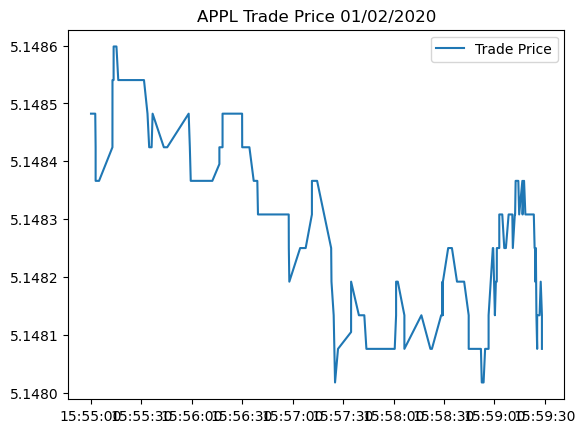

In [3]:
fig,ax=plt.subplots()
ax.plot(trades['Trade_Price'],label='Trade Price')
ax.legend()
ax.set_title("APPL Trade Price 01/02/2020")

In [4]:
vol=trades['Trade_Volume']

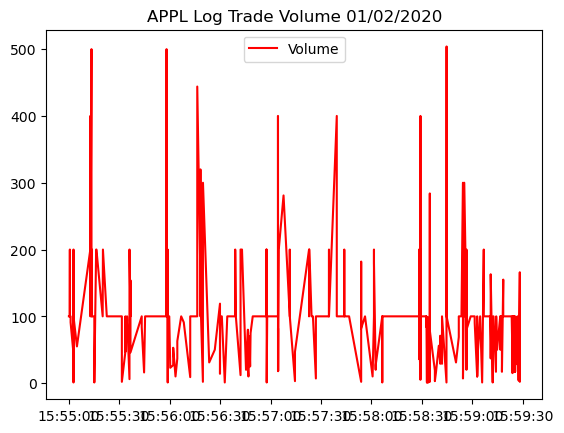

In [5]:
fig,ax=plt.subplots()
ax.set_title("APPL Log Trade Volume 01/02/2020")
ax.plot(vol,color='red',label='Volume')
ax.legend()

### Compute Max Lambda 

As denoted in L1 Trend Filtering, smallest maximum for which $\forall \lambda \geq \lambda_{max}$ the L1 trend filtering returns the best linear affine fit
$$\lambda_{max}=||(DD^T)^{-1}Dy||_\infty$$

For adaptiveness; one idea to show that the max of each component corresponds to the max of that single partition is that the trivial example of the best affine fit between two points simplify to linear interpolation

In [6]:
def max_norm(y,t=None,k=2,adaptive=False,verbose=True):
    
    '''
    
    Computes the smallest max penalty which provides a lower bound of linear affine fits 
    
    * For Efficiency uses scipy sparse matrices as datatype
    * Pascals triangle for fdm computation
    * Optimized returns similar as original but faster!!
    
    
    NEED TO CHANGE MAX_NORM FOR NEW D
    
    
    '''
    D=Dmat(len(y),k)
    
    if t is not None:
        
        t_diff=t
        t_diff1=np.pad(t_diff[1:] ,(0,1),'constant',constant_values=t_diff[-1])
        t_diff3=np.pad(t_diff[:-1],(0,1),'constant',constant_values=t_diff[-1])
        t_diff2=t_diff1+t_diff3 # error in composition 
            
        a=t_diff1/t_diff3
        b=-t_diff2/(t_diff1*t_diff3)
        c=t_diff3/t_diff1
            
        
        # project onto matrix
        T=dia_matrix((np.vstack([a,b,c]),[0,1,2]),shape=(len(y)-2,len(y))).toarray()
           
        # factor into our difference matrix 
        D=T
        
        D=csc_matrix(D)
    else:
        D.tocsc()
   
    D_DT=inv(D@D.T)
    
    
    if not adaptive:
        max_lam=abs(D_DT@D@y).max()
    else:
        max_lam=abs(D_DT@D@y)
        
    if verbose:
        print("Condition Number is ",np.linalg.cond((D@D.T).toarray()))
    return max_lam

In [7]:
lambda_val=max_norm(trades['Trade_Price'].values,k=2)
lambda_val

Condition Number is  1052651210.9105251


/home/jbohn/miniconda3/envs/sepc/lib/python3.10/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:347: SparseEfficiencyWarning: splu converted its input to CSC format
  warn('splu converted its input to CSC format', SparseEfficiencyWarning)
/home/jbohn/miniconda3/envs/sepc/lib/python3.10/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:239: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  warn('spsolve is more efficient when sparse b '


0.9271663496791973

In [8]:
lambda_val=max_norm(trades['Trade_Price'].values,2,True)
plt.title("Adaptive Penalty Bound")

plt.plot(trades['Trade_Price'].index[1:-1],lambda_val,label='Max Norm')
plt.legend()

TypeError: 'int' object is not subscriptable

### Apply Kernel Smoothing on Volume Time Series

Applies Kernel Spatial Smoothing s.t. 

$$\hat{Y}(x_j)=\frac{\sum_{t=1}^T K_\sigma(x_i,x_j)Y(x_i)}{\sum_{t=1}^T K_\sigma(x_i,x_j)}$$ 

Where our kernel function is the Gaussian Kernel

Or we can default to silvermans/scotts (however these have parametric assumptions)

In [9]:
def compute_kernel(x_0,x_i,bandwidth):
    '''
    Given two points x_0 and x_i; compute the gaussian kernel utilizing euclidean distance 
    '''
    scale=abs((x_0-x_i)/bandwidth) # absolute distance in time
    
    weight= np.exp(-scale**2)
      
    return weight

def kernel_smooth(x0,series,pen,bw):
    '''
    x0: index of recent observation
    series: observations
    pen: max lambda to scale kernel to
    
    Note we use the asymptotically optimal bandwidth param for the Epan. Kernel


    '''
    num=0
    ker=0
    
    counter=0
    for index,val in series.items():
        
        kernel=compute_kernel(x0,index,bw) # compute weight as a function of time 
        ker+=kernel
     
        num+=kernel*val*pen[counter] # kernel smoothed series constrained by penalty 

        counter+=1

    return (num/ker)

In [10]:
def smooth_series(k_series,p_series,t=None):
    
    '''
     
    Kernel Smooths a series using the gaussian kerenl
    
    i). Applies Min-Max Normalization to scale -> [0,1]
    ii). Applies Kernel Smoothing with penalty scaling-> [0,1]
    iii). Utilizes Scotts and Silvermans Bandwidth Selection Methods 
        

        
    '''
    
    smooth=[]
    
    
    pen=np.pad(max_norm(p_series.values,t=t,adaptive=True,verbose=False),(1,1))
    
    k_seconds=(k_series.index-k_series.index[0]).total_seconds() 
    normalized_data=(k_series.values-np.min(k_series.values))/(np.max(k_series.values)-np.min(k_series.values))
    
    normalized_series=pd.Series(normalized_data,index=k_seconds)
    
    silver_bw=0.9*min(np.std(k_series),iqr(k_series)/1.35)/(len(k_series)**0.2)
    scott_bw=1.06*np.std(k_series) / (len(k_series)**0.2)
    for x_i_index, x_i in normalized_series.items():
        smoothed_val=kernel_smooth(x_i_index,normalized_series,pen,scott_bw)
        smooth.append(smoothed_val)
   
    smooth=pd.Series(smooth,index=k_series.index)
    
        
    return smooth,pen

In [11]:
smooth,pen=smooth_series(trades['Trade_Volume'],trades['Trade_Price'])

In [12]:
scott_bw=1.06*np.std(trades['Trade_Volume']) / (len(trades['Trade_Volume'])**0.2)
print("Optimal BW is", scott_bw)

Optimal BW is 24.948209512268473


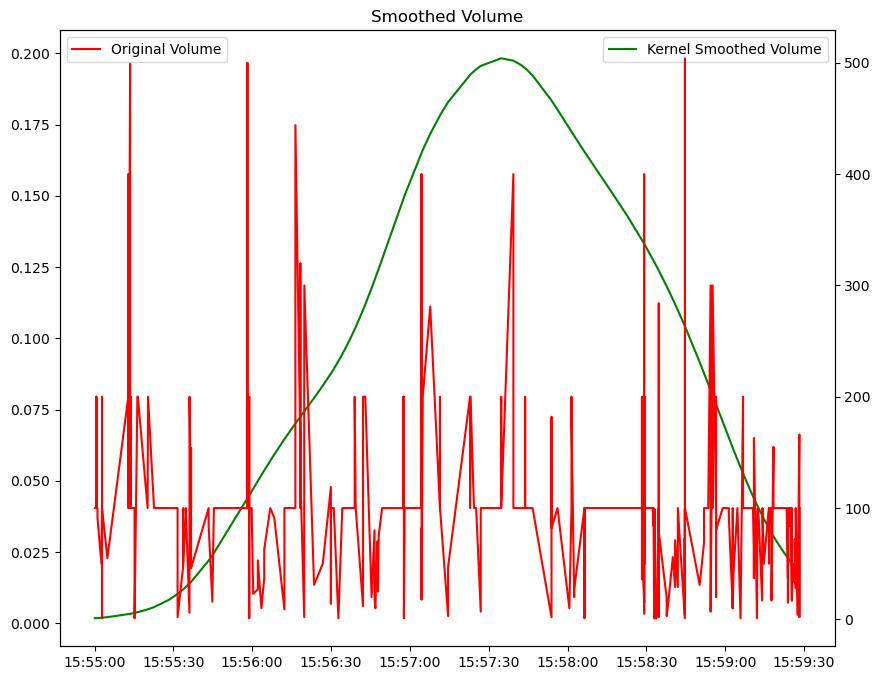

In [13]:
fig,ax=plt.subplots(figsize=(10,8))
ax.plot(smooth.index,smooth.values,label='Kernel Smoothed Volume',color='green')

ax.set_title("Smoothed Volume")
ax2=ax.twinx()
ax2.plot(vol,color='red',label='Original Volume')
ax.legend()
ax2.legend(loc='upper left')

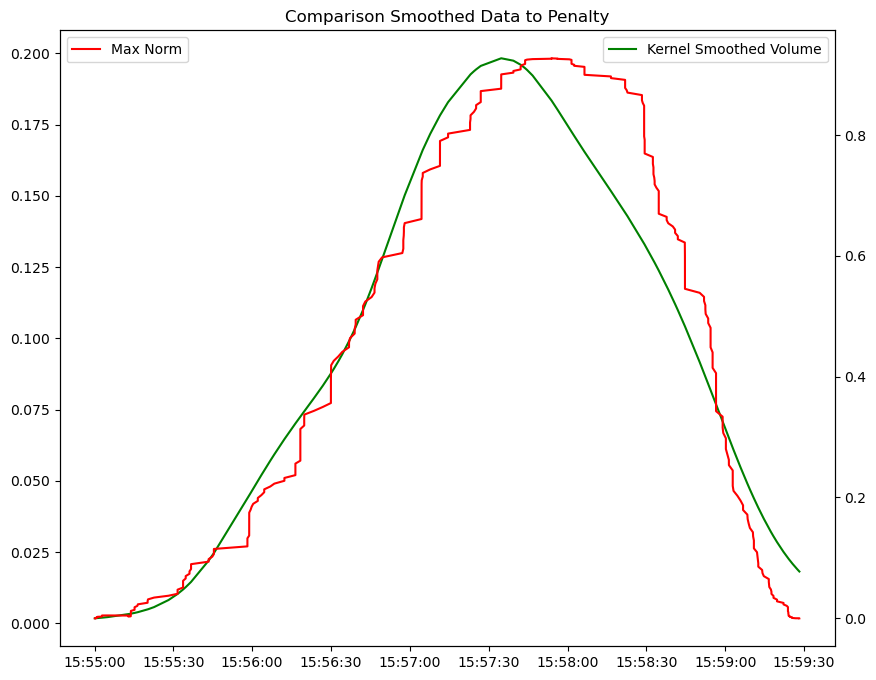

In [14]:
fig,ax=plt.subplots(figsize=(10,8))
ax.plot(smooth.index,smooth.values,label='Kernel Smoothed Volume',color='green')

ax.set_title("Comparison Smoothed Data to Penalty")
ax2=ax.twinx()
ax2.plot(smooth.index,pen,color='red',label='Max Norm')
ax.legend()
ax2.legend(loc='upper left')

### Extension for irregularly spaced time and Adaptive Penalty

### Unit Test 1

For both unit tests we pass in the array of differences in time 

- Uniform spaced time of unit increment

In [15]:
t=np.arange(0,len(trades.index))
t_new=np.pad(np.diff(t),(1,0),'constant',constant_values=t[1])

In [16]:
t_diff=np.pad(np.diff(t),(1,0),'constant',constant_values=t[1]) # difference time occurrences (seconds), pad beginning with 1st observation

# explicitly compute differences 
t_diff1=np.pad(t_diff[1:] ,(0,1),'constant',constant_values=t_diff[-1])
t_diff2=np.pad(t_diff[:-1],(0,1),'constant',constant_values=t[-1])+t_diff1
t_diff3=np.pad(t_diff[:-1],(0,1),'constant',constant_values=t_diff[-1])
      
n=10
# project onto matrix
T=dia_matrix((np.vstack([t_diff3/t_diff1,-t_diff2/(t_diff1*t_diff3),t_diff1/t_diff3]),[0,1,2]),shape=(n-2,n)).toarray()
T

array([[ 1., -2.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  1., -2.,  1.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  1., -2.,  1.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  1., -2.,  1.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  1., -2.,  1.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  1., -2.,  1.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  1., -2.,  1.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  1., -2.,  1.]])

In [17]:
np.linalg.cond(np.linalg.inv(np.matmul(T,T.T)))

298.9691615461861

In [18]:
pen=smooth.values[1:-1].reshape(-1,1)
y=trades['Trade_Price'].values.reshape(-1,1)

x_adapt1,status,eq_D=l1tf_adaptive(y,t=t_new,lambda_p=pen)

solved


In [19]:
eq_inv=np.linalg.inv(np.matmul(eq_D,eq_D.T))

Note the equivalence in difference matrix

Text(0.5, 1.0, 'Adaptive Trend Filtering APPL Trade Price 01/06/2020')

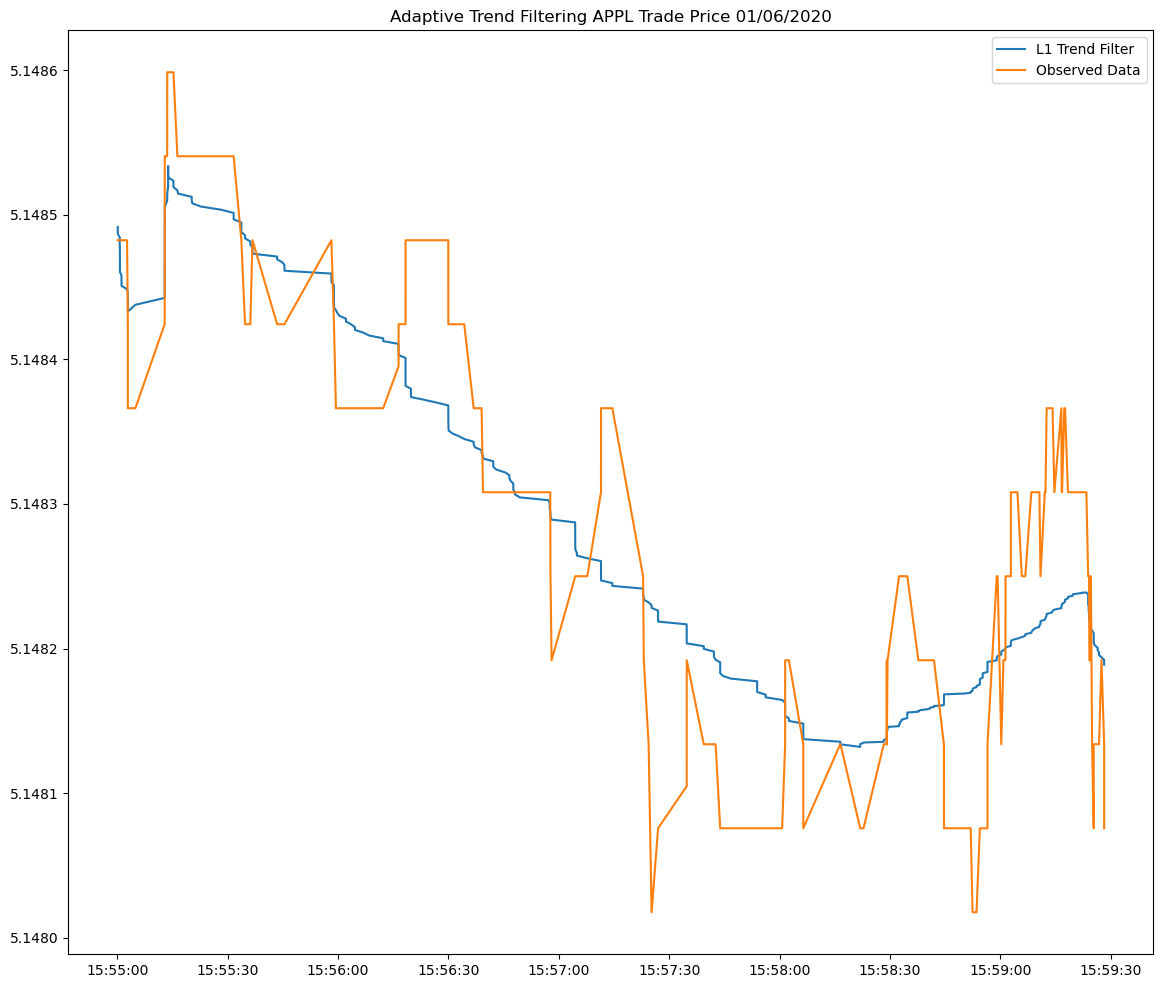

In [20]:
fig,ax=plt.subplots(figsize=(14,12))
ax.plot(trades.index,x_adapt1,label= 'L1 Trend Filter')
ax.plot(trades.index,y, label='Observed Data')


ax.legend()
ax.set_title("Adaptive Trend Filtering APPL Trade Price 01/06/2020")

### Unit Test 2

Uniformly sampled data within the range (0.999999,1.000001)

Leads me to believe the optimization is ill=conditioned 

In [21]:
a=0.9999
b=1.0001

t=np.random.rand(len(trades.index))*(b-a)+a


In [22]:
smooth,pen=smooth_series(trades['Trade_Volume'],trades['Trade_Price'],t)

In [23]:
pen=smooth.values[1:-1].reshape(-1,1)
y=trades['Trade_Price'].values.reshape(-1,1)

x_adapt2,status,D_2=l1tf_adaptive(y,t=t,lambda_p=1.0)

solved


In [24]:
inv_2=np.linalg.inv(D_2.dot(D_2.T))

In [25]:
a=0.99
b=1.01

t=np.random.rand(len(trades.index))*(b-a)+a

In [26]:
pen=smooth.values[1:-1].reshape(-1,1)
y=trades['Trade_Price'].values.reshape(-1,1)

x_adapt3,status,D_3=l1tf_adaptive(y,t=t,lambda_p=1.0)

solved


In [27]:
inv_3=np.linalg.inv(D_3.dot(D_3.T))

In [28]:
a=0
b=2

t=np.random.rand(len(trades.index))*(b-a)+a

In [29]:
pen=smooth.values[1:-1].reshape(-1,1)
y=trades['Trade_Price'].values.reshape(-1,1)

x_adapt4,status,D_4=l1tf_adaptive(y,t=t,lambda_p=1.0)

solved


In [30]:
inv_4=np.linalg.inv(D_4.dot(D_4.T))

Text(0.5, 1.0, 'Equally Spaced with uniform +-1.0 noise ')

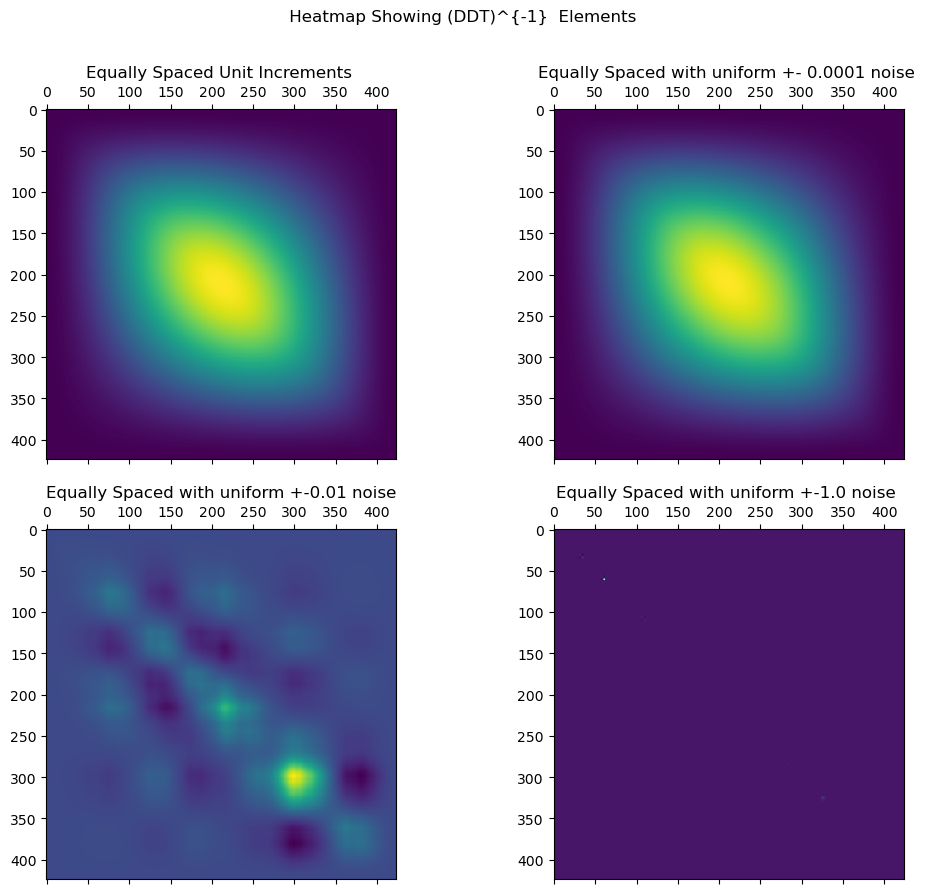

In [31]:
fig,ax=plt.subplots(2,2,figsize=(12,10))
fig.suptitle(" Heatmap Showing (DDT)^{-1}  Elements")
ax[0][0].matshow(eq_inv)
ax[0][0].set_title("Equally Spaced Unit Increments ")
ax[0][1].matshow(inv_2)
ax[0][1].set_title("Equally Spaced with uniform +- 0.0001 noise ")

ax[1][0].matshow(inv_3)
ax[1][0].set_title("Equally Spaced with uniform +-0.01 noise")

ax[1][1].matshow(inv_4)
ax[1][1].set_title("Equally Spaced with uniform +-1.0 noise ")



Text(0.5, 0.98, 'Adaptive Trend Filtering APPL Trade Price 01/06/2020')

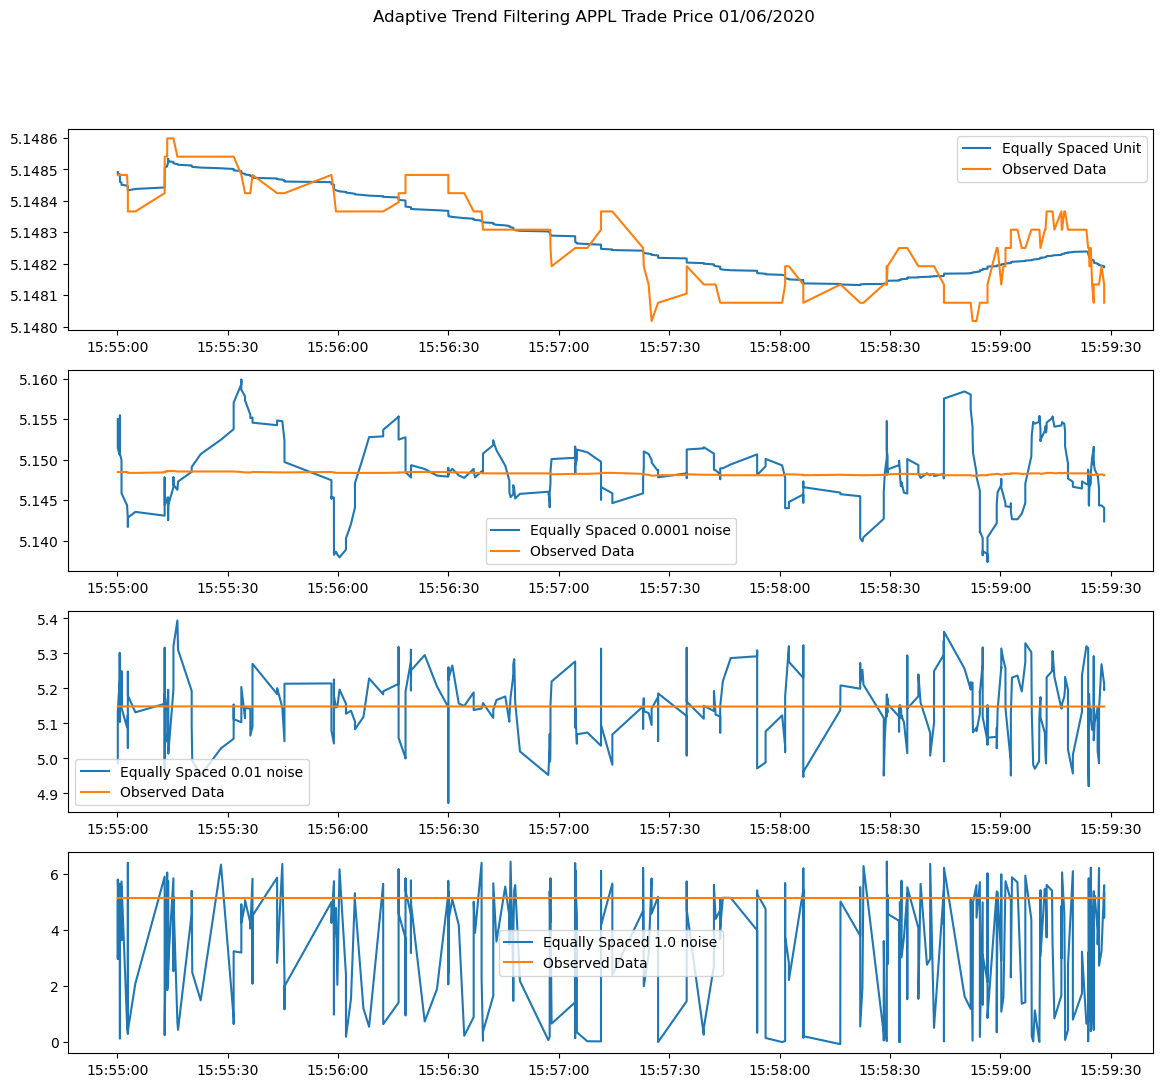

In [32]:
fig,ax=plt.subplots(4,1,figsize=(14,12))
ax[0].plot(trades.index,x_adapt1,label= 'Equally Spaced Unit')
ax[0].plot(trades.index,y, label='Observed Data')

ax[1].plot(trades.index,x_adapt2,label= 'Equally Spaced 0.0001 noise')
ax[1].plot(trades.index,y, label='Observed Data')

ax[2].plot(trades.index,x_adapt3,label= 'Equally Spaced 0.01 noise')
ax[2].plot(trades.index,y, label='Observed Data')

ax[3].plot(trades.index,x_adapt4,label= 'Equally Spaced 1.0 noise')
ax[3].plot(trades.index,y, label='Observed Data')

ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()

fig.suptitle("Adaptive Trend Filtering APPL Trade Price 01/06/2020")